# AIFA — Spesa farmaceutica convenzionata 2022-2024

Preanalysis v0 · DataCivicLab

**Domanda guida:** come si distribuisce la spesa farmaceutica convenzionata per categoria ATC e per regione? Esistono differenze strutturali tra le regioni italiane?

**Fonte:** AIFA — dataset nazionale spesa e consumo farmaceutica convenzionata  
**Copertura:** 2022-2024, granularità anno × mese × regione × ATC4  
**Nota metodologica:** include solo farmaci in regime di convenzione SSN (spesa convenzionata). Escluse spese diretta, DPC, privata.

In [ ]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Percorsi ---
_nb_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
MART_GLOB = os.path.normpath(os.path.join(_nb_dir, "..", "..", "..", "..", "out",
                                           "data", "mart", "aifa_spesa_consumo",
                                           "*", "mart_mensile_regione_atc4.parquet"))

# SAVE_DIR: env var AIFA_SAVE_DIR, oppure sottocartella out/ accanto al notebook
SAVE_DIR = os.environ.get("AIFA_SAVE_DIR") or os.path.join(_nb_dir, "out")
os.makedirs(SAVE_DIR, exist_ok=True)

con = duckdb.connect()

_mart = os.environ.get("AIFA_MART_GLOB", MART_GLOB)
con.execute(f"CREATE VIEW mart AS SELECT * FROM read_parquet('{_mart}')")

df = con.execute("SELECT * FROM mart").df()
print(f"Righe totali: {len(df):,}")
print(f"Anni: {sorted(df.anno.unique())}")
print(f"Regioni: {df.regione.nunique()}")
print(f"Codici ATC4: {df.atc4.nunique()}")
print()
print("Schema:")
print(df.dtypes)
print()
print("Spesa totale per anno (mln EUR):")
print(df.groupby("anno")["spesa_convenzionata"].sum().div(1e6).round(1).to_string())


## 1. Top categorie ATC4 per spesa 2023

La spesa convenzionata si concentra su poche categorie terapeutiche. La prima — **Inibitori della pompa protonica (A02BC)** — vale da sola oltre 650 milioni di euro annui.

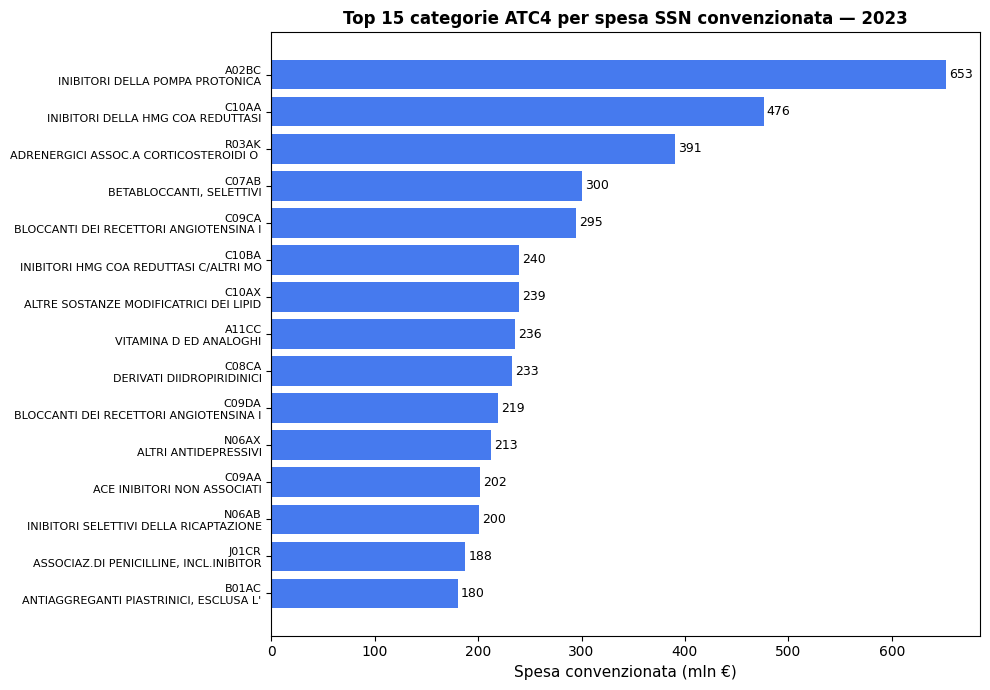

Grafico salvato.


In [2]:
top_atc4 = con.execute("""
    SELECT
        atc4,
        REGEXP_REPLACE(descrizione_atc4, ' \\(.*?\\)', '') AS descrizione,
        SUM(spesa_convenzionata)/1e6 AS spesa_mln
    FROM mart
    WHERE anno = 2023
    GROUP BY atc4, descrizione_atc4
    ORDER BY spesa_mln DESC
    LIMIT 15
""").df()

top_atc4['label'] = top_atc4['atc4'] + '\n' + top_atc4['descrizione'].str[:38]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_atc4['label'][::-1], top_atc4['spesa_mln'][::-1],
               color='#2563EB', alpha=0.85)
ax.set_xlabel('Spesa convenzionata (mln €)', fontsize=11)
ax.set_title('Top 15 categorie ATC4 per spesa SSN convenzionata — 2023', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
for bar, val in zip(bars, top_atc4['spesa_mln'][::-1]):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'aifa_top_atc4_2023.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvato.')

## 2. Trend mensile nazionale 2022-2024

Il profilo mensile è stabile tra gli anni: picchi in **marzo e maggio**, calo consistente in **agosto**. La spesa annua cresce moderatamente da 2022 a 2024.

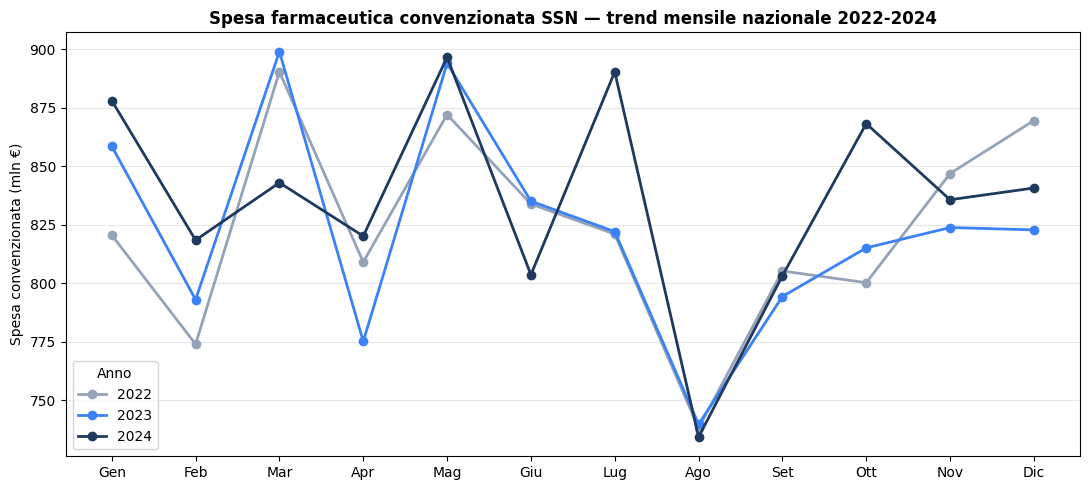

Spesa annua totale (mln €):
  2022: 9,880 mln €
  2023: 9,872 mln €
  2024: 10,032 mln €

Variazione 2022→2024: +1.5%


In [3]:
trend = con.execute("""
    SELECT anno, mese, SUM(spesa_convenzionata)/1e6 AS spesa_mln
    FROM mart
    GROUP BY anno, mese
    ORDER BY anno, mese
""").df()

mesi_etichette = ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic']
colori = {2022: '#94A3B8', 2023: '#3B82F6', 2024: '#1E3A5F'}

fig, ax = plt.subplots(figsize=(11, 5))
for anno, grp in trend.groupby('anno'):
    ax.plot(grp['mese'], grp['spesa_mln'], marker='o', linewidth=2,
            color=colori[anno], label=str(anno))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mesi_etichette)
ax.set_ylabel('Spesa convenzionata (mln €)')
ax.set_title('Spesa farmaceutica convenzionata SSN — trend mensile nazionale 2022-2024',
             fontsize=12, fontweight='bold')
ax.legend(title='Anno')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'aifa_trend_mensile_2022_2024.png'), dpi=150, bbox_inches='tight')
plt.show()

# Key numbers
totali = trend.groupby('anno')['spesa_mln'].sum()
print('Spesa annua totale (mln €):')
for anno, val in totali.items():
    print(f'  {anno}: {val:,.0f} mln €')
print(f'\nVariazione 2022→2024: {(totali[2024]/totali[2022]-1)*100:+.1f}%')

## 3. Confronto regionale — spesa totale 2023

**Lombardia, Campania e Lazio** pesano per oltre il 40% della spesa convenzionata nazionale. Le regioni del Sud mostrano spese elevate non proporzionali alla sola dimensione demografica.

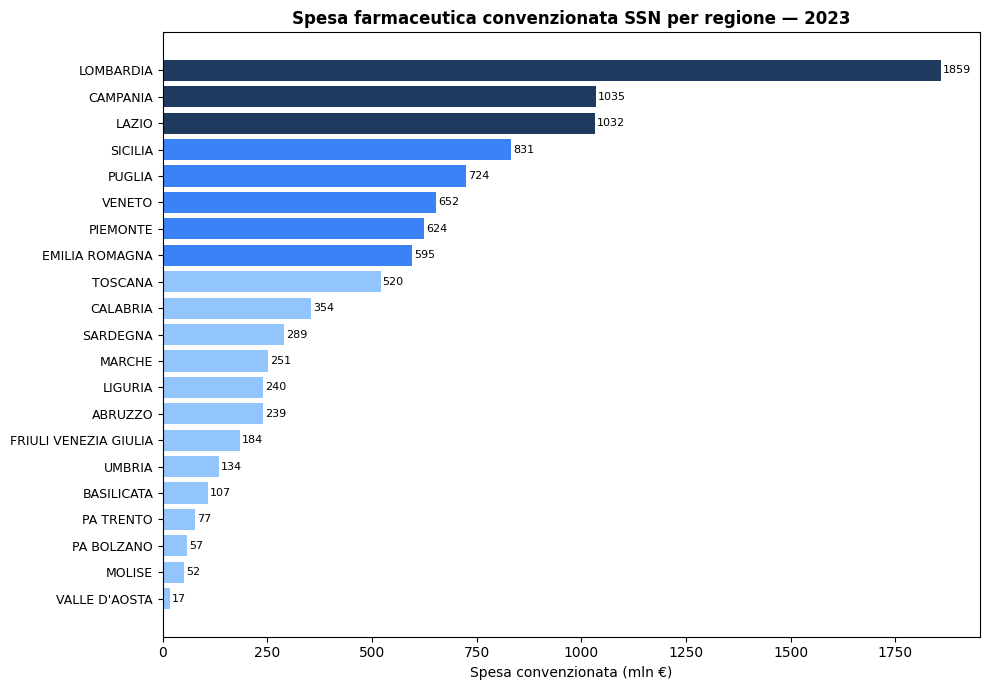

Spesa totale nazionale 2023: 9,872 mln €
Quota top 3 regioni: 39.8%


In [4]:
regioni = con.execute("""
    SELECT regione, SUM(spesa_convenzionata)/1e6 AS spesa_mln
    FROM mart
    WHERE anno = 2023
    GROUP BY regione
    ORDER BY spesa_mln DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 7))
colori_reg = ['#1E3A5F' if i < 3 else '#3B82F6' if i < 8 else '#93C5FD'
              for i in range(len(regioni))]
bars = ax.barh(regioni['regione'][::-1], regioni['spesa_mln'][::-1], color=colori_reg[::-1])
ax.set_xlabel('Spesa convenzionata (mln €)')
ax.set_title('Spesa farmaceutica convenzionata SSN per regione — 2023',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, regioni['spesa_mln'][::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=8)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'aifa_spesa_regioni_2023.png'), dpi=150, bbox_inches='tight')
plt.show()

totale_naz = regioni['spesa_mln'].sum()
top3_pct = regioni.head(3)['spesa_mln'].sum() / totale_naz * 100
print(f'Spesa totale nazionale 2023: {totale_naz:,.0f} mln €')
print(f'Quota top 3 regioni: {top3_pct:.1f}%')

## 4. Spesa pro capite per regione — 2023

Correggendo per la popolazione, il quadro cambia: **Campania e Calabria** emergono come regioni con spesa convenzionata pro capite più alta d'Italia. Le regioni del Nord (Lombardia, PA Bolzano) scendono nella graduatoria.

*Popolazione ISTAT 2023 (dati.istat.it — popolazione residente per regione).*

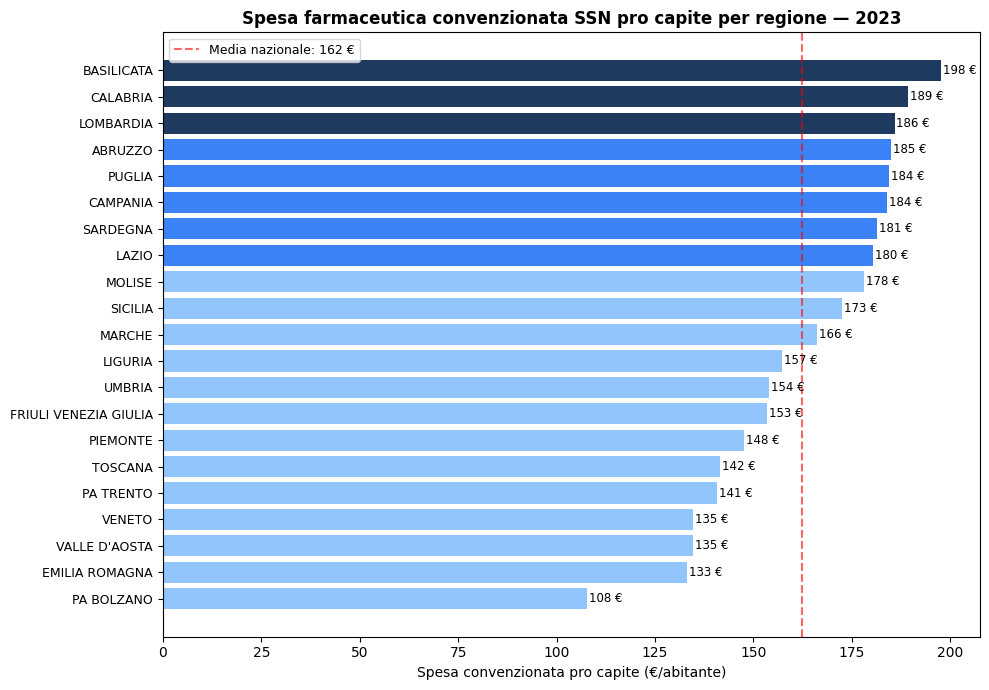

Media nazionale: 162 €/abitante
Regione con spesa pro capite più alta: BASILICATA (198 €)
Regione con spesa pro capite più bassa: PA BOLZANO (108 €)
Rapporto max/min: 1.8x


In [5]:
# Popolazione regionale ISTAT 2023 (migliaia di residenti)
pop_istat_2023 = {
    'PIEMONTE': 4228_000,
    'VALLE D\'AOSTA': 124_000,
    'LOMBARDIA': 10_006_000,
    'PA BOLZANO': 534_000,
    'PA TRENTO': 546_000,
    'VENETO': 4_838_000,
    'FRIULI VENEZIA GIULIA': 1_200_000,
    'LIGURIA': 1_524_000,
    'EMILIA ROMAGNA': 4_468_000,
    'TOSCANA': 3_673_000,
    'UMBRIA': 868_000,
    'MARCHE': 1_510_000,
    'LAZIO': 5_720_000,
    'ABRUZZO': 1_293_000,
    'MOLISE': 290_000,
    'CAMPANIA': 5_624_000,
    'PUGLIA': 3_927_000,
    'BASILICATA': 541_000,
    'CALABRIA': 1_870_000,
    'SICILIA': 4_819_000,
    'SARDEGNA': 1_590_000,
}

pop_df = pd.DataFrame(list(pop_istat_2023.items()), columns=['regione', 'popolazione'])
regioni_pc = regioni.merge(pop_df, on='regione', how='left')
regioni_pc['spesa_pro_capite'] = (regioni_pc['spesa_mln'] * 1e6) / regioni_pc['popolazione']
regioni_pc = regioni_pc.sort_values('spesa_pro_capite', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colori_pc = ['#1E3A5F' if i < 3 else '#3B82F6' if i < 8 else '#93C5FD'
             for i in range(len(regioni_pc))]
bars = ax.barh(regioni_pc['regione'][::-1], regioni_pc['spesa_pro_capite'][::-1],
               color=colori_pc[::-1])
ax.set_xlabel('Spesa convenzionata pro capite (€/abitante)')
ax.set_title('Spesa farmaceutica convenzionata SSN pro capite per regione — 2023',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, regioni_pc['spesa_pro_capite'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f} €',
            va='center', fontsize=8.5)
ax.tick_params(axis='y', labelsize=9)
ax.axvline(regioni_pc['spesa_pro_capite'].mean(), color='red', linestyle='--',
           alpha=0.6, label=f'Media nazionale: {regioni_pc["spesa_pro_capite"].mean():.0f} €')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'aifa_spesa_procapite_regioni_2023.png'), dpi=150, bbox_inches='tight')
plt.show()

media = regioni_pc['spesa_pro_capite'].mean()
print(f'Media nazionale: {media:.0f} €/abitante')
print(f'Regione con spesa pro capite più alta: {regioni_pc.iloc[0]["regione"]} ({regioni_pc.iloc[0]["spesa_pro_capite"]:.0f} €)')
print(f'Regione con spesa pro capite più bassa: {regioni_pc.iloc[-1]["regione"]} ({regioni_pc.iloc[-1]["spesa_pro_capite"]:.0f} €)')
print(f'Rapporto max/min: {regioni_pc["spesa_pro_capite"].max()/regioni_pc["spesa_pro_capite"].min():.1f}x')

## Note metodologiche

- **Perimetro:** solo farmaci in convenzione SSN (spesa convenzionata). Escluse spesa diretta (ospedali), DPC, spesa privata.
- **Fonte:** AIFA — Open Data spesa e consumo farmaceutica, file nazionali mensili 2022-2024.
- **Granularità mart:** anno × mese × regione × ATC4. Le analisi pro capite usano la classificazione ATC4 aggregata a livello regionale annuo.
- **Popolazione:** ISTAT 2023 — valori approssimati (residenti per regione). Le Province Autonome (PA Bolzano, PA Trento) sono trattate come unità regionali separate.
- **Copertura temporale:** 2022-2024 (3 anni). Gli anni 2016-2021 sono disponibili nella fonte AIFA ma non ancora scaricati in questo dataset.
- **Limitazioni v0:** non include confronto con DRG/LEA, non normalizza per struttura demografica (età), non collega a esiti sanitari.

---
*DataCivicLab · Preanalysis v0 · Marzo 2026*